# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



This playbook turns the existing baseline action scores into a practical review queue.

The queue is intended to help a human reviewer decide which content items may be worth reviewing first. The score is used for prioritization, not as proof that an action will improve performance.

The baseline uses observable content and performance signals to assign a score, reason code, and suggested action. Because the Week-5 random-split accuracy was 70.13% but decreased to 57.24% under a client-grouped split, these recommendations should be treated as directional decision-support rather than a production prediction system.

The most important review principle is: **higher priority means "review first", not "automatically change."**

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
INPUT_PATH = Path("../outputs/baseline_action_score.csv")
OUTPUT_DIR = Path("../outputs")

# Load the existing baseline queue
df = pd.read_csv(INPUT_PATH)

print("Input shape:", df.shape)
print("\nColumns available:")
print(df.columns.tolist())

# Basic validation
required_columns = [
    "content_id",
    "score",
    "reason_code",
    "action"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Rank by the existing baseline score
queue = df.copy()

queue["score"] = pd.to_numeric(
    queue["score"],
    errors="coerce"
).fillna(0)

queue = queue.sort_values(
    ["score"],
    ascending=False
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)

# Put rank first
queue = queue[
    ["rank"] +
    [col for col in queue.columns if col != "rank"]
]

print("\nTop 10 ranked items:")
display(
    queue[
        ["rank", "content_id", "score", "reason_code", "action"]
    ].head(10)
)

Input shape: (30000, 47)

Columns available:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'score', 'reason_code', 'action']

Top 10 ranked items:


,rank,content_id,score,reason_code,action
0,1,content_cf56e2e2e282,61678,STALE_HIGH_IMPRESSIONS,Refresh Content
1,2,content_7368877ea310,59472,STALE_HIGH_IMPRESSIONS,Refresh Content
2,3,content_1bfaa38ff26c,25715,STALE_HIGH_IMPRESSIONS,Refresh Content
3,4,content_0a91db491d14,13299,STALE_HIGH_IMPRESSIONS,Refresh Content
4,5,content_5feee3994adb,7812,STALE_HIGH_IMPRESSIONS,Refresh Content
5,6,content_c2d929d83eaa,7558,STALE_HIGH_IMPRESSIONS,Refresh Content
6,7,content_b16bd7307b39,4590,STALE_HIGH_IMPRESSIONS,Refresh Content
7,8,content_fe16a55cd13d,4556,STALE_HIGH_IMPRESSIONS,Refresh Content
8,9,content_ecb6215e79fd,4429,STALE_HIGH_IMPRESSIONS,Refresh Content
9,10,content_928af3e22c80,1697,STALE_HIGH_IMPRESSIONS,Refresh Content


In [6]:
# Reason-code and action summary
reason_summary = (
    queue
    .groupby(["reason_code", "action"], dropna=False)
    .agg(
        items=("content_id", "count"),
        median_score=("score", "median"),
        max_score=("score", "max")
    )
    .reset_index()
    .sort_values(
        ["max_score", "items"],
        ascending=[False, False]
    )
)

display(reason_summary)

,reason_code,action,items,median_score,max_score
1,STALE_HIGH_IMPRESSIONS,Refresh Content,17,4429.0,61678
0,NO_ACTION,Monitor,29983,0.0,0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended use and limits

### Intended use

This action playbook is intended for content teams, analysts, and researchers who need to prioritize content for human review.

Its main purpose is to answer:

> Which content items look worth reviewing first, and why?

The ranked queue can support:

- prioritizing content for possible refresh review;
- identifying older or stale content that may deserve attention;
- identifying content with strong existing exposure that may have review value;
- organizing a content-review backlog;
- comparing the main reasons items were prioritized.

The queue is **decision-support**, not an automatic decision system. A high score means that an item is prioritized for review; it does not mean that taking the suggested action will improve performance.

### Limits

The evidence comes from the available FlyRank dataset and its validation design. The original random split produced 70.13% accuracy, while the client-grouped split produced 57.24% accuracy. This difference suggests that the random-split result may give an optimistic view of generalization to unseen clients.

The model and action queue should therefore not be described as a production-grade prediction system or as a guarantee of future content performance.

The analysis is observational rather than a controlled experiment. The observed patterns can support review prioritization, but they do not establish that a specific content action causes better performance.

The recommendations also depend on the quality, coverage, and definitions of the available data. Missing values, differences between content types, and changes in measurement systems may affect the reliability of individual recommendations.

The playbook should be re-evaluated if the data distribution, content portfolio, measurement system, or business objective changes substantially.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



### Human review rules

Every recommendation in the action queue must be reviewed by a person before any content change is made.

The reviewer should:

1. Confirm that the content is still relevant to the intended audience and business context.
2. Check the page's actual search intent and whether the content satisfies that intent.
3. Review the assigned reason code and supporting data signals.
4. Check for important context that is not represented in the dataset.
5. Decide whether the suggested action is appropriate for the specific page.
6. Record whether the recommendation was accepted, rejected, or requires further investigation.

The score and reason code should help the reviewer prioritize their work, but they should not replace editorial judgment.

### No-go list

The following decisions should **not** be automated using this playbook:

- Automatically rewriting or publishing content.
- Automatically deleting content.
- Automatically changing search intent.
- Automatically changing factual claims.
- Automatically changing medical, financial, legal, or other high-stakes information.
- Automatically changing canonical URLs or redirects.
- Automatically changing internal-link structure without human review.
- Automatically deciding that a page has no business value.
- Automatically applying a refresh to every item above a score threshold.
- Automatically claiming that a refresh caused an improvement in performance.

The system can recommend which items to review first. A human must make the final decision about what action, if any, should be taken.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



The action playbook should be monitored over time because content portfolios, data distributions, and measurement systems can change.

### Monitoring

The following signals should be checked periodically:

- Distribution of baseline action scores.
- Number of items assigned to each reason code.
- Number of items assigned to each recommended action.
- Missingness in important input fields.
- Changes in the mix of content types.
- Changes in content age and freshness distributions.
- Changes in observed performance metrics.
- Human acceptance and rejection of recommendations.
- Differences between validation performance and later observed performance.

### Re-evaluation triggers

The playbook should be re-evaluated when:

1. Important input distributions change materially.
2. Reason-code or action frequencies change substantially.
3. New content types or measurement systems are introduced.
4. Important input fields become unavailable or their definitions change.
5. Reviewers frequently reject the same type of recommendation.
6. Observed outcomes no longer resemble the patterns used to construct the baseline.
7. The business objective changes.

### Retraining or rebuilding triggers

Retraining or rebuilding should be considered when there is sustained distribution shift, repeated changes in the data-generating process, or evidence that the current validation results no longer support the intended decision-support use.

A new model should be evaluated using a client-grouped or time-aware validation design before replacing the existing baseline.

Retraining should not be triggered by a single poor recommendation or a small number of unusual cases. The decision should be based on a sustained pattern supported by monitoring data.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked queue and reason-code summary are exported to `work/outputs/` for reproducibility. A summary figure is saved to `work/figures/` for possible reuse in the research paper. The paper-facing queue excludes client and content identifiers.

In [3]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
FIGURES_DIR = Path("../figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

paper_queue = queue[
    ["rank", "score", "reason_code", "action"]
].copy()

queue_path = OUTPUT_DIR / "w07_ranked_action_queue.csv"

paper_queue.to_csv(
    queue_path,
    index=False
)

print("Ranked queue saved to:")
print(queue_path)

print("Queue shape:", paper_queue.shape)

display(paper_queue.head(10))

Ranked queue saved to:
..\outputs\w07_ranked_action_queue.csv
Queue shape: (30000, 4)


,rank,score,reason_code,action
0,1,61678,STALE_HIGH_IMPRESSIONS,Refresh Content
1,2,59472,STALE_HIGH_IMPRESSIONS,Refresh Content
2,3,25715,STALE_HIGH_IMPRESSIONS,Refresh Content
3,4,13299,STALE_HIGH_IMPRESSIONS,Refresh Content
4,5,7812,STALE_HIGH_IMPRESSIONS,Refresh Content
5,6,7558,STALE_HIGH_IMPRESSIONS,Refresh Content
6,7,4590,STALE_HIGH_IMPRESSIONS,Refresh Content
7,8,4556,STALE_HIGH_IMPRESSIONS,Refresh Content
8,9,4429,STALE_HIGH_IMPRESSIONS,Refresh Content
9,10,1697,STALE_HIGH_IMPRESSIONS,Refresh Content


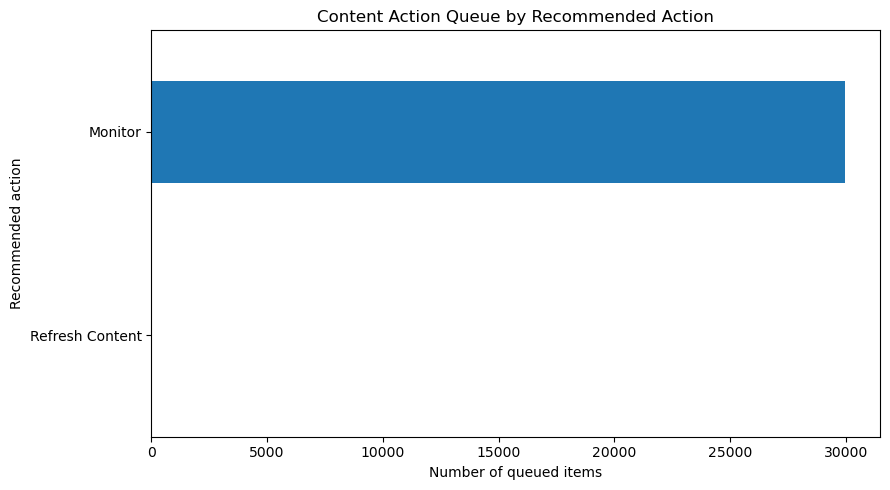

Figure saved to:
..\figures\w07_action_queue_by_action.png


In [4]:
import matplotlib.pyplot as plt

action_counts = (
    queue["action"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
action_counts.plot(kind="barh")

plt.xlabel("Number of queued items")
plt.ylabel("Recommended action")
plt.title("Content Action Queue by Recommended Action")

plt.tight_layout()

figure_path = FIGURES_DIR / "w07_action_queue_by_action.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [5]:
reason_export = (
    queue
    .groupby(["reason_code", "action"], dropna=False)
    .agg(
        items=("score", "size"),
        median_score=("score", "median"),
        max_score=("score", "max")
    )
    .reset_index()
    .sort_values(
        ["max_score", "items"],
        ascending=[False, False]
    )
)

reason_path = OUTPUT_DIR / "w07_reason_code_summary.csv"

reason_export.to_csv(
    reason_path,
    index=False
)

print("Reason-code summary saved to:")
print(reason_path)

display(reason_export)

Reason-code summary saved to:
..\outputs\w07_reason_code_summary.csv


,reason_code,action,items,median_score,max_score
1,STALE_HIGH_IMPRESSIONS,Refresh Content,17,4429.0,61678
0,NO_ACTION,Monitor,29983,0.0,0


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.